# WORKPLACE WELLBEING AND MENTAL FATIGUE:

GROUP MEMBERS:

MUNAZZAH TARIQ CS-23115
DUAA ZAHEER CS-23113
HAMNA BANO CS-23120

## *MILESTONE:2

### 1. LOAD THE DATASET
loading the dataset in Jupyter Notebook.

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
df=pd.read_excel("responses.csv")
df.head()

,Timestamp,What is your age? (enter number),What is your Gender?,Are you self-employed?,Do you have a family history of mental health conditions?,How many employees work at your company? (enter approximate number),Do you work remotely?,Does your workplace provide mental health benefits?,Does your workplace offer mental health care options?,Does your company have a wellness or stress-management program?,Would you feel comfortable seeking help for a mental health issue?,Would you feel comfortable discussing mental health concerns anonymously?,How easily would your workplace allow leave for mental health reasons?,Do you think discussing mental health at work could negatively affect your career?,Would you feel comfortable discussing mental health concerns with your supervisor?,How often does your work negatively interfere with your mental health?
0,2026-02-15 18:11:01.816,25,Female,No,No,500,No,No,No,No,Don't Know,Yes,Somewhat difficult,Maybe,No,Often
1,2026-02-15 18:12:07.407,26,Female,No,Yes,56,No,No,Don't Know,No,No,Yes,Somewhat difficult,Yes,Some of them,Often
2,2026-02-15 18:17:31.796,45,Male,No,No,200,No,No,No,Yes,Yes,Yes,Somewhat easy,Yes,No,Sometimes
3,2026-02-15 18:18:06.159,56,Male,No,Yes,40,No,Yes,Yes,Yes,Yes,Yes,Very easy,No,yes,Never
4,2026-02-15 18:19:48.205,45,Male,No,Yes,200,No,Yes,No,Yes,Yes,Yes,Very easy,Yes,yes,Sometimes


#### CHECK DATASET SHAPE
Finding total entries and columns in the dataset.

In [106]:
#identifying the total number of rows and columns.
df.shape

(506, 16)

### 2. INSPECT THE DATASET
This shows:

1. column names
2. data types
3. missing values

In [107]:
#gives information about the columns and their datatypes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 16 columns):
 #   Column                                                                                 Non-Null Count  Dtype         
---  ------                                                                                 --------------  -----         
 0   Timestamp                                                                              506 non-null    datetime64[ns]
 1   What is your age? (enter number)                                                       506 non-null    object        
 2   What is your Gender?                                                                   506 non-null    object        
 3   Are you self-employed?                                                                 506 non-null    object        
 4   Do you have a family history of mental health conditions?                              506 non-null    object        
 5   How many employees work at yo

In [108]:
#Checks for missing value in the table.
df.isnull().sum()

,0
Timestamp,0
What is your age? (enter number),0
What is your Gender?,0
Are you self-employed?,0
Do you have a family history of mental health conditions?,0
How many employees work at your company? (enter approximate number),1
Do you work remotely?,0
Does your workplace provide mental health benefits?,0
Does your workplace offer mental health care options?,0
Does your company have a wellness or stress-management program?,0


### 3. RENAMING THE COLUMNS

In this step, since the data has been collected through surveys, we change the names of the columns respectively.

We also removed any hidden spaces from columns before renaming it.

In [109]:
#Identify the columns
df.columns

Index(['Timestamp', 'What is your age? (enter number)', 'What is your Gender?',
       'Are you self-employed?',
       'Do you have a family history of mental health conditions?',
       'How many employees work at your company? (enter approximate number)',
       'Do you work remotely?',
       'Does your workplace provide mental health benefits?  ',
       'Does your workplace offer mental health care options?  ',
       'Does your company have a wellness or stress-management program?  ',
       'Would you feel comfortable seeking help for a mental health issue?  ',
       'Would you feel comfortable discussing mental health concerns anonymously?',
       'How easily would your workplace allow leave for mental health reasons?',
       ' Do you think discussing mental health at work could negatively affect your career?  ',
       'Would you feel comfortable discussing mental health concerns with your supervisor?',
       'How often does your work negatively interfere with your mental

In [110]:
#Remove hidden spaces between from column names.
df.columns=df.columns.str.strip()

In [111]:
#Renaming the columns.
df=df.rename(columns={
'What is your age? (enter number)': 'Age',
'What is your Gender?': 'Gender',
'Are you self-employed?': 'Self_employed',
'Do you have a family history of mental health conditions?': 'Family_history',
'How many employees work at your company? (enter approximate number)': 'No_employees',
'Do you work remotely?': 'Remote_work',
'Does your workplace provide mental health benefits?': 'Benefits',
'Does your workplace offer mental health care options?': 'Care_options',
'Does your company have a wellness or stress-management program?': 'Wellness_program',
'Would you feel comfortable seeking help for a mental health issue?': 'Seek_help',
'Would you feel comfortable discussing mental health concerns anonymously?': 'Anonymity',
'How easily would your workplace allow leave for mental health reasons?': 'Leave',
'Do you think discussing mental health at work could negatively affect your career?': 'Mental_health_consequences',
'Would you feel comfortable discussing mental health concerns with your supervisor?': 'Supervisor',
'How often does your work negatively interfere with your mental health?': 'Work_interfere'
})

In [112]:
#Removing the timestamp column as it is not of any value.
df=df.drop(columns=['Timestamp'], errors='ignore')

In [113]:
#Verify the change in column names.
df.columns

Index(['Age', 'Gender', 'Self_employed', 'Family_history', 'No_employees',
       'Remote_work', 'Benefits', 'Care_options', 'Wellness_program',
       'Seek_help', 'Anonymity', 'Leave', 'Mental_health_consequences',
       'Supervisor', 'Work_interfere'],
      dtype='object')

### 4. BASIC EXPLORATORY DATA ANALYSIS (EDA):
EDA was performed on Age, Gender, and Work Interference to understand how different age groups and genders are affected by mental health in the workplace. This analysis helps identify patterns or trends, such as whether certain age groups experience more work interference due to mental health issues, or if gender differences exist in how work impacts mental health.

#### FOR AGE DISTRIBUTION:

In [114]:
#Identify the datatype of the Age column.
print(df['Age'].head(10))
print(df['Age'].dtype)

0    25
1    26
2    45
3    56
4    45
5    30
6    49
7    32
8    23
9    33
Name: Age, dtype: object
object


In [115]:
#Convert Age to numeric, turn invalid strings to NaN
#Using df.loc ensures assignment is done safely on all rows of the column
df.loc[:,'Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [116]:
#Drop rows where Age is NaN
df=df.dropna(subset=['Age']).copy()

In [117]:
#Keep only ages between 17 and 70
df=df[df['Age'].between(17, 70)].copy()

In [118]:
#Convert Age to integer
df.loc[:,'Age']=df['Age'].astype(int)

In [119]:
#Check
print(df['Age'].head(10))
print(df['Age'].dtype)

0    25
1    26
2    45
3    56
4    45
5    30
6    49
7    32
8    23
9    33
Name: Age, dtype: object
object


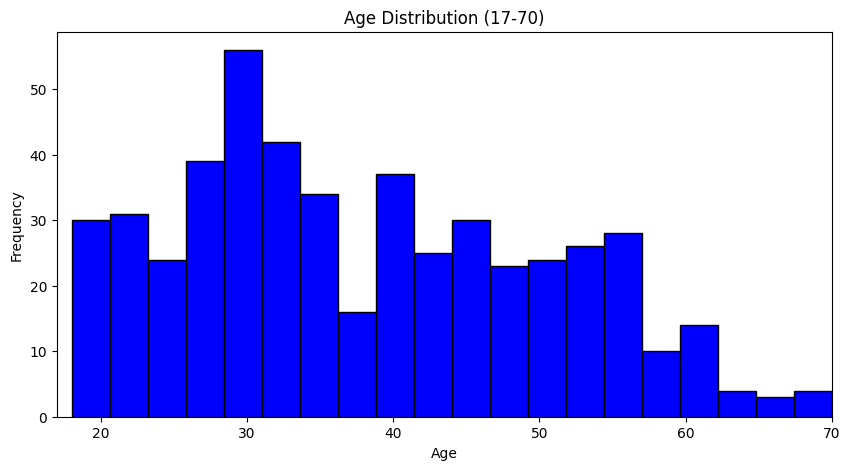

In [120]:
#The following graph is plotted against frequency to demonstrate the frequency with which certain ages occur in the table
plt.figure(figsize=(10,5))
plt.hist(df['Age'], bins=20, color='blue', edgecolor='black')
plt.title("Age Distribution (17-70)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xlim(17, 70)
plt.show()

#### FOR GENDER DISTRIBUTION:

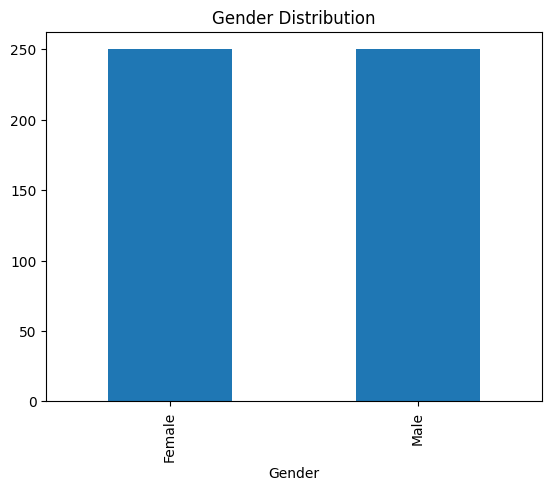

In [121]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

#### FOR WORK_INTERFERENCE (TARGET):

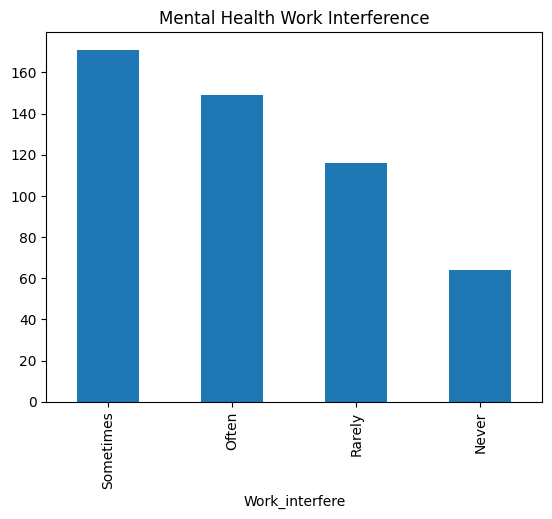

In [122]:
df['Work_interfere'].value_counts().plot(kind='bar')
plt.title("Mental Health Work Interference")
plt.show()

### 5. HANDLING MISSING VALUES:
If missing values still exist we handle it.

In [123]:
df.isnull().sum()

,0
Age,0
Gender,0
Self_employed,0
Family_history,0
No_employees,1
Remote_work,0
Benefits,0
Care_options,0
Wellness_program,0
Seek_help,0


In [124]:
# Set pandas option to use the future behavior for downcasting object-type columns.
# This suppresses the FutureWarning when filling missing values in categorical columns.
pd.set_option('future.no_silent_downcasting', True)
df = df.fillna(df.mode().iloc[0])

In [125]:
df.isnull().sum()

,0
Age,0
Gender,0
Self_employed,0
Family_history,0
No_employees,0
Remote_work,0
Benefits,0
Care_options,0
Wellness_program,0
Seek_help,0


### 6. ENCODE CATEGORICAL VARIABLES:

In [126]:
scaler = StandardScaler()
df[['Age']] = scaler.fit_transform(df[['Age']])

In [127]:
# Map true binary Yes/No columns to 1/0
binary_cols = ['Self_employed', 'Family_history', 'Remote_work', 'Benefits']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0, 'yes':1, 'no':0})

In [128]:
 # Map multi-class columns
df['Care_options'] = df['Care_options'].map({"No":0, "Don't Know":1, "Yes":2})
df['Wellness_program'] = df['Wellness_program'].map({"No":0, "Don't Know":1, "Yes":2})
df['Seek_help'] = df['Seek_help'].map({"No":0, "Don't Know":1, "Yes":2})
df['Anonymity'] = df['Anonymity'].map({"No":0, "Don't Know":1, "Yes":2})

# Leave column (ordinal)
df['Leave'] = df['Leave'].map({
    "Very easy":0,
    "Somewhat easy":1,
    "Don't Know":2,
    "Somewhat difficult":3,
    "Very difficult":4
})

# Supervisor: 3 values
df['Supervisor'] = df['Supervisor'].map({
    'No': 0, 'no': 0,
    'Some of them': 1,
    'Yes': 2, 'yes': 2
})

# Mental_health_consequences
df['Mental_health_consequences'] = df['Mental_health_consequences'].map({"No":0, "Maybe":1, "Yes":2})

# Gender (binary for simplicity; add other categories if needed)
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

In [129]:
#Encode No_employees (company size) into ordinal bins
def categorize_employees(val):
    if pd.isna(val):
        return 2   # fallback (mode)
    if isinstance(val, str):
        if 'More than' in val:
            return 2   # 101‑500 bin
        digits = ''.join(filter(str.isdigit, val))
        val = int(digits) if digits else 200
    val = int(val)
    if val <= 25:
        return 0
    elif val <= 100:
        return 1
    elif val <= 500:
        return 2
    elif val <= 1000:
        return 3
    elif val <= 5000:
        return 4
    else:
        return 5

df['No_employees'] = df['No_employees'].apply(categorize_employees)

In [130]:
#Create binary target (0 = Never, 1 = any interference)
df['Work_interfere'] = df['Work_interfere'].replace({
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 1,
    'Often': 1
})

In [131]:
df = df.fillna(df.mode().iloc[0])

In [132]:
print(df.isnull().sum())   # should be all zeros
print(df.dtypes)

Age                           0
Gender                        0
Self_employed                 0
Family_history                0
No_employees                  0
Remote_work                   0
Benefits                      0
Care_options                  0
Wellness_program              0
Seek_help                     0
Anonymity                     0
Leave                         0
Mental_health_consequences    0
Supervisor                    0
Work_interfere                0
dtype: int64
Age                           float64
Gender                          int64
Self_employed                   int64
Family_history                  int64
No_employees                    int64
Remote_work                     int64
Benefits                        int64
Care_options                    int64
Wellness_program                int64
Seek_help                       int64
Anonymity                       int64
Leave                           int64
Mental_health_consequences      int64
Supervisor   

In [133]:
df.head(20)

,Age,Gender,Self_employed,Family_history,No_employees,Remote_work,Benefits,Care_options,Wellness_program,Seek_help,Anonymity,Leave,Mental_health_consequences,Supervisor,Work_interfere
0,-1.057709,0,0,0,2,0,0,0,0,1,2,3,1,0,1
1,-0.976296,0,0,1,1,0,0,1,0,0,2,3,2,1,1
2,0.570537,1,0,0,2,0,0,0,2,2,2,1,2,0,1
3,1.466073,1,0,1,1,0,1,2,2,2,2,0,0,2,0
4,0.570537,1,0,1,2,0,1,0,2,2,2,0,2,2,1
5,-0.650647,0,1,0,0,1,1,2,0,2,2,0,0,0,1
6,0.896187,0,0,1,1,0,1,1,1,1,0,4,2,1,1
7,-0.487822,1,1,0,2,1,0,0,0,2,2,1,0,2,1
8,-1.220533,1,0,0,4,0,1,1,2,2,2,2,1,2,1
9,-0.406410,1,1,0,0,0,1,0,0,2,2,1,2,0,1


In [134]:
df['Work_interfere'] = df['Work_interfere'].astype(int)

In [135]:
print("Missing values after preprocessing:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Missing values after preprocessing:
 Age                           0
Gender                        0
Self_employed                 0
Family_history                0
No_employees                  0
Remote_work                   0
Benefits                      0
Care_options                  0
Wellness_program              0
Seek_help                     0
Anonymity                     0
Leave                         0
Mental_health_consequences    0
Supervisor                    0
Work_interfere                0
dtype: int64

Data types:
 Age                           float64
Gender                          int64
Self_employed                   int64
Family_history                  int64
No_employees                    int64
Remote_work                     int64
Benefits                        int64
Care_options                    int64
Wellness_program                int64
Seek_help                       int64
Anonymity                       int64
Leave                           int64


In [136]:
# Example
X = df.drop('Work_interfere', axis=1)
y = df['Work_interfere']

## *MILESTONE:3

### Spliting the dataset
Dataset split into training, validation, and test sets
Split 1: 70% training, 15% validation, 15% testing (test_size=0.3 then split temp equally)
Split 2: 80% training, 10% validation, 10% testing (test_size=0.2 then split temp equally)
This is done to analyze the effect of different data split ratios on model performance

#### SPLIT:01

In [137]:
#Split :01
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

### LOGISTIC REGRESSION
For non-parametric model we chose logistic regression and trained three models for it.
1. log1
2. log2
3. log3

In [138]:
from sklearn.linear_model import LogisticRegression

log1 = LogisticRegression(C=0.1)
log2 = LogisticRegression(C=1)
log3 = LogisticRegression(C=10)

log1.fit(X_train, y_train)
log2.fit(X_train, y_train)
log3.fit(X_train, y_train)

LogisticRegression(C=10)

In [139]:
print(log1.coef_)
print(log2.coef_)
print(log3.coef_)

[[-0.28182621 -0.00918981 -0.08193836  0.2002684  -0.02602565 -0.07606504
  -0.33089489 -0.17854007  0.02510128  0.13448909 -0.02479432  0.47017516
   0.36613942 -0.33125517]]
[[-0.35261122  0.02939119 -0.1458821   0.4676619  -0.03007772 -0.16629594
  -0.81305577 -0.15385142  0.13830786  0.25995625 -0.00716493  0.57521202
   0.43049137 -0.3824182 ]]
[[-0.36433665  0.04179442 -0.16332872  0.54586059 -0.02467433 -0.20289437
  -0.99087518 -0.12941951  0.17273849  0.28467373 -0.00654727  0.59378707
   0.43391075 -0.38799415]]


### DECISION TREES
For the parametric model, we have used a decision tree model and trained three models for it with varying depths.
1. tree1 (max_depth=3)
3. tree2 (max_depth=5)
4. tree3 (max_depth=10)

In [140]:
from sklearn.tree import DecisionTreeClassifier

tree1 = DecisionTreeClassifier(max_depth=3)
tree2 = DecisionTreeClassifier(max_depth=5)
tree3 = DecisionTreeClassifier(max_depth=10)

tree1.fit(X_train, y_train)
tree2.fit(X_train, y_train)
tree3.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

### NEURAL NETWORK
All models use:
1. ReLU activation in hidden layers
2. Sigmoid activation in output layer (binary classification)
3. Binary cross-entropy loss function
#### FOR MODEL 1:
Single hidden layer (32 neurons)
Simple architecture
Used as a baseline neural network model

In [141]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

nn1 = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    Dense(1, activation='sigmoid')
])

nn1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn1.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7171 - loss: 0.6125 - val_accuracy: 0.8267 - val_loss: 0.5263
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8429 - loss: 0.4888 - val_accuracy: 0.8667 - val_loss: 0.4512
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8686 - loss: 0.4333 - val_accuracy: 0.8800 - val_loss: 0.4146
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8743 - loss: 0.4019 - val_accuracy: 0.8800 - val_loss: 0.3953
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8714 - loss: 0.3838 - val_accuracy: 0.8800 - val_loss: 0.3784
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8686 - loss: 0.3645 - val_accuracy: 0.8800 - val_loss: 0.3664
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8686 - loss: 0.3506 - val_accuracy: 0.8800 - val_loss: 0.3566
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8686 - loss: 0.3386 - val_accuracy: 0.8800 - val_loss: 0.3491

#### FOR MODEL:2
Two hidden layers (64, 32 neurons)
Deeper architecture to capture more complex patterns

In [142]:
nn2 = Sequential([
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn2.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8571 - loss: 0.4908 - val_accuracy: 0.8800 - val_loss: 0.3926
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8714 - loss: 0.3717 - val_accuracy: 0.8800 - val_loss: 0.3531
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8714 - loss: 0.3470 - val_accuracy: 0.8800 - val_loss: 0.3445
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8714 - loss: 0.3338 - val_accuracy: 0.8800 - val_loss: 0.3311
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8714 - loss: 0.3202 - val_accuracy: 0.8800 - val_loss: 0.3223
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8714 - loss: 0.3106 - val_accuracy: 0.8800 - val_loss: 0.3165
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8771 - loss: 0.3031 - val_accuracy: 0.8800 - val_loss: 0.3124
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8829 - loss: 0.2949 - val_accuracy: 0.8800 - val

#### FOR MODEL:3
Same architecture as model 2
Uses Adam optimizer with custom learning rate (0.001)
Designed to test impact of optimizer tuning on performance

In [143]:
from tensorflow.keras.optimizers import Adam

nn3 = Sequential([
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn3.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])
nn3.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8229 - loss: 0.5294 - val_accuracy: 0.8800 - val_loss: 0.4392
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8714 - loss: 0.3866 - val_accuracy: 0.8800 - val_loss: 0.3710
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8714 - loss: 0.3485 - val_accuracy: 0.8800 - val_loss: 0.3555
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8714 - loss: 0.3339 - val_accuracy: 0.8800 - val_loss: 0.3473
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8714 - loss: 0.3227 - val_accuracy: 0.8800 - val_loss: 0.3405
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8714 - loss: 0.3147 - val_accuracy: 0.8800 - val_loss: 0.3354
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8771 - loss: 0.3074 - val_accuracy: 0.8933 - val_loss: 0.3327
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8829 - loss: 0.3016 - val_accuracy: 0.8933 - val_los

### EVALUATION OF MODELS
We calculated performance metrics of all the models
1. Accuracy
2. Precision
3. Recall
4. F1_score

Then we individually evaluate each model (logistic, decision tree, Custom neural network)

In [144]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

In [145]:
#store results
results = {}

In [146]:
#logistic Regression
results["log1"] = evaluate_model(log1, X_test, y_test)
results["log2"] = evaluate_model(log2, X_test, y_test)
results["log3"] = evaluate_model(log3, X_test, y_test)

In [147]:
#decision tree
results["tree1"] = evaluate_model(tree1, X_test, y_test)
results["tree2"] = evaluate_model(tree2, X_test, y_test)
results["tree3"] = evaluate_model(tree3, X_test, y_test)

In [148]:
#neural network
nn1_pred = (nn1.predict(X_test) > 0.5).astype(int)
nn2_pred = (nn2.predict(X_test) > 0.5).astype(int)
nn3_pred = (nn3.predict(X_test) > 0.5).astype(int)

results["nn1"] = {
    "Accuracy": accuracy_score(y_test, nn1_pred),
    "Precision": precision_score(y_test, nn1_pred),
    "Recall": recall_score(y_test, nn1_pred),
    "F1": f1_score(y_test, nn1_pred)
}

results["nn2"] = {
    "Accuracy": accuracy_score(y_test, nn2_pred),
    "Precision": precision_score(y_test, nn2_pred),
    "Recall": recall_score(y_test, nn2_pred),
    "F1": f1_score(y_test, nn2_pred)
}

results["nn3"] = {
    "Accuracy": accuracy_score(y_test, nn3_pred),
    "Precision": precision_score(y_test, nn3_pred),
    "Recall": recall_score(y_test, nn3_pred),
    "F1": f1_score(y_test, nn3_pred)
}

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [149]:
results_df = pd.DataFrame(results).T
print(results_df)

       Accuracy  Precision    Recall        F1
log1   0.853333   0.864865  0.984615  0.920863
log2   0.853333   0.875000  0.969231  0.919708
log3   0.853333   0.875000  0.969231  0.919708
tree1  0.893333   0.890411  1.000000  0.942029
tree2  0.906667   0.926471  0.969231  0.947368
tree3  0.880000   0.924242  0.938462  0.931298
nn1    0.880000   0.888889  0.984615  0.934307
nn2    0.880000   0.888889  0.984615  0.934307
nn3    0.840000   0.873239  0.953846  0.911765


### COMPARISON BETWEEN MODELS:
After evaluating the performance metrics of every model, we then compare these models using their F1_scores.

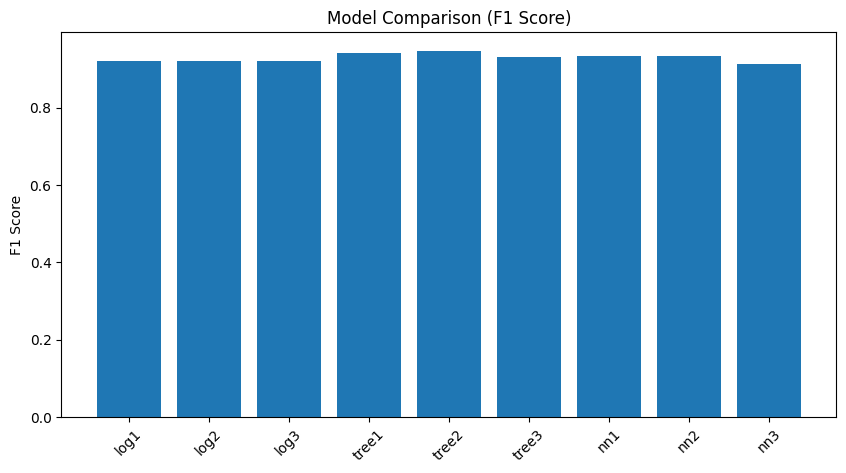

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(results_df.index, results_df["F1"])
plt.xticks(rotation=45)
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")

plt.show()

In [151]:
best_model_name = results_df["F1"].idxmax()
best_f1 = results_df["F1"].max()

print("Best Model:", best_model_name)
print("Best F1 Score:", best_f1)

Best Model: tree2
Best F1 Score: 0.9473684210526315


It was concluded that Decision tree model 2(tree2) performed better than all models we have trained, therefore we again tested model 2 of the decision tree by splitting the dataset into different ratios:

In [152]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

tree_best = tree2  # your best decision tree model
tree_best.fit(X_train, y_train)

pred1 = tree_best.predict(X_test)

print("Split 1 F1:", f1_score(y_test, pred1))

Split 1 F1: 0.9473684210526315


In [153]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

tree_best.fit(X_train, y_train)

pred2 = tree_best.predict(X_test)

print("Split 2 F1:", f1_score(y_test, pred2))

Split 2 F1: 0.9534883720930233


INTERACTIVE INTEERFACE! FIND OUT IF YOUR WORK INTERFERES WITH YOUR MENTAL HEALTH
The test cases were performed using the best model from all the models we trained

In [154]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd


def encode_binary(v):
    return 1 if str(v).lower() == 'yes' else 0

def encode_care_options(v):
    return {'No':0, "Don't Know":1, 'Yes':2}.get(v, 1)

def encode_wellness(v):
    return {'No':0, "Don't Know":1, 'Yes':2}.get(v, 1)

def encode_seek_help(v):
    return {'No':0, "Don't Know":1, 'Yes':2}.get(v, 1)

def encode_anonymity(v):
    return {'No':0, "Don't Know":1, 'Yes':2}.get(v, 1)

def encode_leave(v):
    return {'Very easy':0, 'Somewhat easy':1, "Don't Know":2,
            'Somewhat difficult':3, 'Very difficult':4}.get(v, 2)

def encode_supervisor(v):
    return {'No':0, 'Some of them':1, 'Yes':2}.get(v, 0)

def encode_consequences(v):
    return {'No':0, 'Maybe':1, 'Yes':2}.get(v, 1)

def encode_gender(v):
    return 0 if v == 'Female' else 1

def categorize_employees(val):
    if isinstance(val, str):
        digits = ''.join(filter(str.isdigit, val))
        val = int(digits) if digits else 200
    else:
        val = int(val)
    if val <= 25: return 0
    elif val <= 100: return 1
    elif val <= 500: return 2
    elif val <= 1000: return 3
    elif val <= 5000: return 4
    else: return 5

# Building interactive widgets
age_slider = widgets.IntSlider(value=30, min=17, max=70, step=1, description='Age:')
gender_drop = widgets.Dropdown(options=['Female', 'Male'], value='Female', description='Gender:')
self_emp_drop = widgets.Dropdown(options=['No', 'Yes'], value='No', description='Self‑employed:')
fam_history_drop = widgets.Dropdown(options=['No', 'Yes'], value='No', description='Family history:')
num_emp_input = widgets.IntText(value=50, description='# employees:')
remote_drop = widgets.Dropdown(options=['No', 'Yes'], value='No', description='Remote work:')
benefits_drop = widgets.Dropdown(options=['No', 'Yes'], value='No', description='Benefits:')
care_drop = widgets.Dropdown(options=['No', "Don't Know", 'Yes'], value="Don't Know", description='Care options:')
wellness_drop = widgets.Dropdown(options=['No', "Don't Know", 'Yes'], value="Don't Know", description='Wellness prog.:')
seek_drop = widgets.Dropdown(options=['No', "Don't Know", 'Yes'], value="Don't Know", description='Seek help:')
anonymity_drop = widgets.Dropdown(options=['No', "Don't Know", 'Yes'], value="Don't Know", description='Anonymity:')
leave_drop = widgets.Dropdown(options=['Very easy', 'Somewhat easy', "Don't Know", 'Somewhat difficult', 'Very difficult'],
                              value="Don't Know", description='Leave ease:')
supervisor_drop = widgets.Dropdown(options=['No', 'Some of them', 'Yes'], value='Some of them', description='Supervisor:')
consequences_drop = widgets.Dropdown(options=['No', 'Maybe', 'Yes'], value='Maybe', description='Career consequences:')

predict_btn = widgets.Button(description='Predict Work Interference')
output = widgets.Output()

def on_predict(b):
    with output:
        clear_output()
        # Scale age
        age_scaled = scaler.transform([[age_slider.value]])[0,0]
        features = np.array([[
            age_scaled,
            encode_gender(gender_drop.value),
            encode_binary(self_emp_drop.value),
            encode_binary(fam_history_drop.value),
            categorize_employees(num_emp_input.value),
            encode_binary(remote_drop.value),
            encode_binary(benefits_drop.value),
            encode_care_options(care_drop.value),
            encode_wellness(wellness_drop.value),
            encode_seek_help(seek_drop.value),
            encode_anonymity(anonymity_drop.value),
            encode_leave(leave_drop.value),
            encode_consequences(consequences_drop.value),
            encode_supervisor(supervisor_drop.value)
        ]])
        pred = tree2.predict(features)[0]
        msg = "Work interferes with mental health" if pred == 1 else "Work does NOT interfere with mental health"
        print(msg)

predict_btn.on_click(on_predict)

def predict_from_dict(data):
    age_scaled = scaler.transform([[data['Age']]])[0,0]
    feats = [
        age_scaled,
        encode_gender(data['Gender']),
        encode_binary(data['Self_employed']),
        encode_binary(data['Family_history']),
        categorize_employees(data['No_employees']),
        encode_binary(data['Remote_work']),
        encode_binary(data['Benefits']),
        encode_care_options(data['Care_options']),
        encode_wellness(data['Wellness_program']),
        encode_seek_help(data['Seek_help']),
        encode_anonymity(data['Anonymity']),
        encode_leave(data['Leave']),
        encode_consequences(data['Mental_health_consequences']),
        encode_supervisor(data['Supervisor'])
    ]
    return tree2.predict([feats])[0]

# ---------- Three test cases ----------
test1 = {
    'Age': 25, 'Gender': 'Female', 'Self_employed': 'No', 'Family_history': 'No',
    'No_employees': 200, 'Remote_work': 'Yes', 'Benefits': 'Yes', 'Care_options': 'Yes',
    'Wellness_program': 'Yes', 'Seek_help': 'Yes', 'Anonymity': 'Yes', 'Leave': 'Very easy',
    'Supervisor': 'Yes', 'Mental_health_consequences': 'No'
}
test2 = {
    'Age': 55, 'Gender': 'Male', 'Self_employed': 'Yes', 'Family_history': 'Yes',
    'No_employees': 10, 'Remote_work': 'No', 'Benefits': 'No', 'Care_options': 'No',
    'Wellness_program': 'No', 'Seek_help': 'No', 'Anonymity': 'No', 'Leave': 'Very difficult',
    'Supervisor': 'No', 'Mental_health_consequences': 'Yes'
}
test3 = {
    'Age': 38, 'Gender': 'Female', 'Self_employed': 'No', 'Family_history': 'Yes',
    'No_employees': 500, 'Remote_work': 'No', 'Benefits': 'Yes', 'Care_options': "Don't Know",
    'Wellness_program': "Don't Know", 'Seek_help': 'Yes', 'Anonymity': 'Yes', 'Leave': 'Somewhat difficult',
    'Supervisor': 'Some of them', 'Mental_health_consequences': 'Maybe'
}

print("="*50)
print("THREE TEST CASE PREDICTIONS (using tree2)")
print("-"*50)
print("Test 1 (good environment):", "Interference" if predict_from_dict(test1) else "No interference")
print("Test 2 (poor environment):", "Interference" if predict_from_dict(test2) else "No interference")
print("Test 3 (mixed):", "Interference" if predict_from_dict(test3) else "No interference")
print("="*50)
print("\nNow use the interactive form below to try your own scenario:\n")

# Display the interface
display(age_slider, gender_drop, self_emp_drop, fam_history_drop,
        num_emp_input, remote_drop, benefits_drop, care_drop,
        wellness_drop, seek_drop, anonymity_drop, leave_drop,
        supervisor_drop, consequences_drop, predict_btn, output)

THREE TEST CASE PREDICTIONS (using tree2)
--------------------------------------------------
Test 1 (good environment): No interference
Test 2 (poor environment): Interference
Test 3 (mixed): Interference

Now use the interactive form below to try your own scenario:



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-pac

IntSlider(value=30, description='Age:', max=70, min=17)

Dropdown(description='Gender:', options=('Female', 'Male'), value='Female')

Dropdown(description='Self‑employed:', options=('No', 'Yes'), value='No')

...

Dropdown(description='Leave ease:', index=2, options=('Very easy', 'Somewhat easy', "Don't Know", 'Somewhat di…

Dropdown(description='Supervisor:', index=1, options=('No', 'Some of them', 'Yes'), value='Some of them')

Dropdown(description='Career consequences:', index=1, options=('No', 'Maybe', 'Yes'), value='Maybe')

Button(description='Predict Work Interference', style=ButtonStyle())

Output()